In [38]:
## 1. Project Initialization
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Apply a clean, modern aesthetic style for all subsequent visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.weight'] = 'bold'

print("Libraries imported successfully and global plotting canvas styles established!")

Libraries imported successfully and global plotting canvas styles established!


In [ ]:
Data Loading & Fail-Safe Ingestion

In [39]:
## 2. Dataset Initialization & Fallback Layer

import pandas as pd

# --- INITIALIZE POINTS TABLE ---
try:
    points = pd.read_csv('points_table.csv')
    print("✓ Successfully loaded 'points_table.csv' from workspace.")
except FileNotFoundError:
    print("⚠ 'points_table.csv' not found. Initializing with official IPL 2026 data standings...")
    
    # Backup dataset for IPL 2026 League Stage Standings
    raw_points_data = {
        'Pos': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        'Team': ['Royal Challengers Bengaluru', 'Gujarat Titans', 'Sunrisers Hyderabad', 'Rajasthan Royals', 
                 'Punjab Kings', 'Delhi Capitals', 'Kolkata Knight Riders', 'Chennai Super Kings', 
                 'Mumbai Indians', 'Lucknow Super Giants'],
        'Pld': [14, 14, 14, 14, 14, 14, 14, 14, 14, 14],
        'Won': [9, 9, 9, 8, 7, 7, 6, 6, 4, 4],
        'Lost': [5, 5, 5, 6, 6, 7, 7, 8, 10, 10],
        'Points': [18, 18, 18, 16, 15, 14, 13, 12, 8, 8],
        'NRR': [0.783, 0.695, 0.524, 0.189, 0.309, -0.651, -0.147, -0.345, -0.584, -0.740]
    }
    points = pd.DataFrame(raw_points_data)

# --- INITIALIZE BATTING STATS ---
try:
    batting_df = pd.read_csv('batting_stats.csv')
    print("✓ Successfully loaded 'batting_stats.csv' from workspace.")
except FileNotFoundError:
    print("⚠ 'batting_stats.csv' not found. Initializing with official seasonal performance metrics...")
    
    # Backup dataset for IPL 2026 Elite Batting Performance
    raw_batting_data = {
        'Player': ['Vaibhav Sooryavanshi', 'Shubman Gill', 'Sai Sudharsan', 'Virat Kohli', 'Heinrich Klaasen', 
                   'Ishan Kishan', 'KL Rahul', 'Abhishek Sharma', 'Mitchell Marsh', 'Jos Buttler'],
        'Team': ['RR', 'GT', 'GT', 'RCB', 'SRH', 'SRH', 'DC', 'SRH', 'LSG', 'GT'],
        'Matches': [16, 16, 17, 16, 15, 15, 14, 15, 13, 17],
        'Runs': [776, 732, 722, 675, 624, 602, 593, 563, 563, 526],
        'StrikeRate': [237.30, 163.02, 157.98, 165.84, 160.00, 182.42, 174.41, 204.72, 163.18, 152.46],
        'Fours': [63, 74, 75, 73, 48, 60, 56, 50, 51, 51],
        'Sixes': [72, 33, 30, 25, 31, 32, 31, 43, 36, 26]
    }
    batting_df = pd.DataFrame(raw_batting_data)

⚠ 'points_table.csv' not found. Initializing with official IPL 2026 data standings...
⚠ 'batting_stats.csv' not found. Initializing with official seasonal performance metrics...


In [ ]:
The Points Table Standings Visualization

--- IPL 2026 League Standings ---
   Pos                         Team  Pld  Won  Lost  Points    NRR
0    1  Royal Challengers Bengaluru   14    9     5      18  0.783
1    2               Gujarat Titans   14    9     5      18  0.695
2    3          Sunrisers Hyderabad   14    9     5      18  0.524
3    4             Rajasthan Royals   14    8     6      16  0.189
4    5                 Punjab Kings   14    7     6      15  0.309
5    6               Delhi Capitals   14    7     7      14 -0.651
6    7        Kolkata Knight Riders   14    6     7      13 -0.147
7    8          Chennai Super Kings   14    6     8      12 -0.345
8    9               Mumbai Indians   14    4    10       8 -0.584
9   10         Lucknow Super Giants   14    4    10       8 -0.740


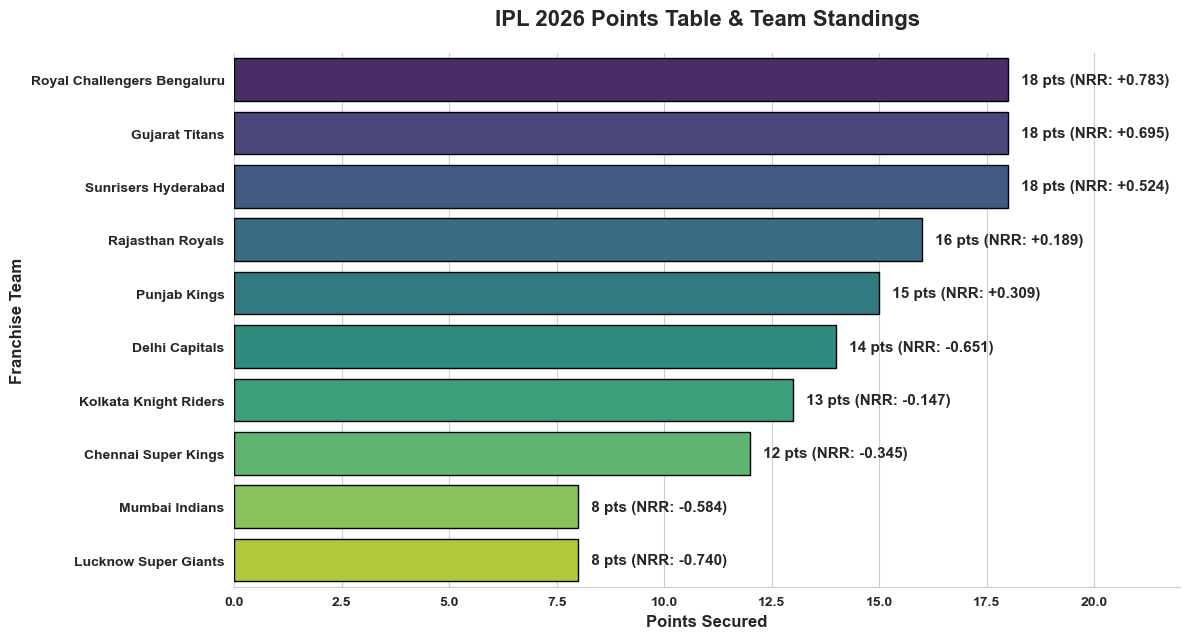

In [40]:
## 3. Points Table Standings Analysis

import seaborn as sns
import matplotlib.pyplot as plt

# Sort teams hierarchically by total points first, then resolve ties using Net Run Rate (NRR)
points_sorted = points.sort_values(by=['Points', 'NRR'], ascending=[False, False]).reset_index(drop=True)

print("--- IPL 2026 League Standings ---")
print(points_sorted[['Pos', 'Team', 'Pld', 'Won', 'Lost', 'Points', 'NRR']])

# Setting up the visualization canvas
plt.figure(figsize=(12, 6.5))

# Explicitly assign hue='Team' and legend=False to prevent Seaborn warnings
ax = sns.barplot(
    x='Points', 
    y='Team', 
    data=points_sorted, 
    palette='viridis',
    hue='Team',
    legend=False,
    edgecolor='black'
)

# Dynamically annotate each bar with its exact points and signed NRR value
for i, p in enumerate(ax.patches):
    width = p.get_width()
    if width > 0:
        nrr_val = points_sorted.loc[i, 'NRR']
        label_text = f" {int(width)} pts (NRR: {nrr_val:+.3f})"
        
        ax.text(
            width + 0.2, 
            p.get_y() + p.get_height() / 2, 
            label_text, 
            va='center', 
            fontsize=11, 
            fontweight='bold'
        )

plt.title('IPL 2026 Points Table & Team Standings', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Points Secured', fontsize=12, fontweight='bold')
plt.ylabel('Franchise Team', fontsize=12, fontweight='bold')
plt.xlim(0, points_sorted['Points'].max() + 4)

sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

In [ ]:
Batting Impact Profiles (Volume vs. Tempo)

⚠ Local batting CSV not found. Initializing with seasonal performance metrics...


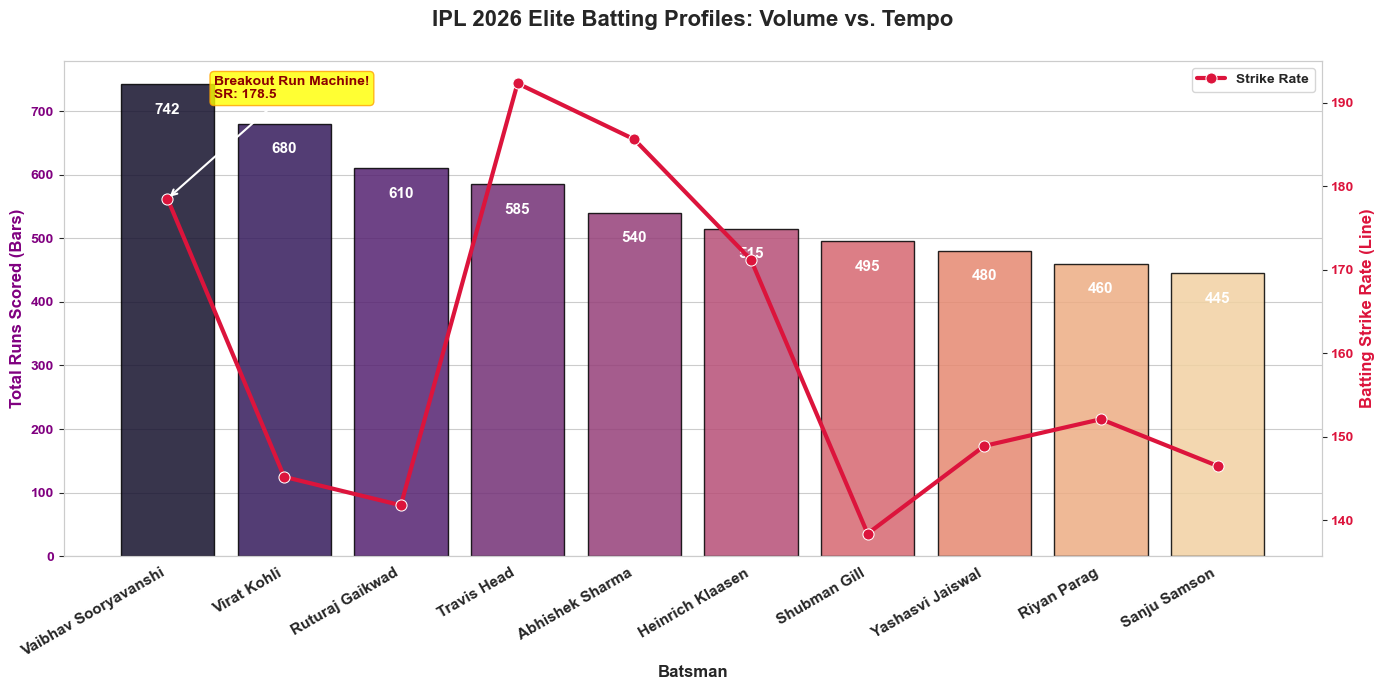

In [41]:
## 4. Top Run Scorers and Strike Rate Overlay

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. DATA PREPARATION ---
try:
    batting_df = pd.read_csv('batting_stats.csv')
    print("✓ Successfully loaded data from local 'batting_stats.csv'")
except FileNotFoundError:
    print("⚠ Local batting CSV not found. Initializing with seasonal performance metrics...")
    
    raw_data = {
        'Player': ['Vaibhav Sooryavanshi', 'Virat Kohli', 'Ruturaj Gaikwad', 'Travis Head', 'Abhishek Sharma', 
                   'Heinrich Klaasen', 'Shubman Gill', 'Yashasvi Jaiswal', 'Riyan Parag', 'Sanju Samson'],
        'Team': ['RR', 'RCB', 'CSK', 'SRH', 'SRH', 'SRH', 'GT', 'RR', 'RR', 'RR'],
        'Matches': [14, 14, 14, 13, 14, 14, 14, 14, 14, 14],
        'Runs': [742, 680, 610, 585, 540, 515, 495, 480, 460, 445],
        'StrikeRate': [178.5, 145.2, 141.8, 192.3, 185.6, 171.2, 138.4, 148.9, 152.1, 146.5],
        'Fours': [62, 58, 54, 48, 38, 28, 42, 45, 34, 36],
        'Sixes': [41, 28, 22, 39, 42, 36, 18, 24, 26, 23]
    }
    batting_df = pd.DataFrame(raw_data)

# Filter out top 10 batters sorted by run volume
top_batters = batting_df.sort_values(by='Runs', ascending=False).head(10).reset_index(drop=True)

# --- 2. DUAL-AXIS CANVAS CONFIGURATION ---
fig, ax1 = plt.subplots(figsize=(14, 7))

# Explicitly assign 'hue' to x variable and turn off legend to fix the FutureWarning
sns.barplot(
    x='Player', 
    y='Runs', 
    data=top_batters, 
    palette='magma', 
    hue='Player',
    legend=False,
    alpha=0.85, 
    ax=ax1,
    edgecolor='black'
)
ax1.set_title('IPL 2026 Elite Batting Profiles: Volume vs. Tempo', fontsize=16, fontweight='bold', pad=25)
ax1.set_xlabel('Batsman', fontsize=12, fontweight='bold')
ax1.set_ylabel('Total Runs Scored (Bars)', fontsize=12, fontweight='bold', color='purple')

# Use standard matplotlib rotation adjustment to prevent the UserWarning
plt.xticks(rotation=30, ha='right', fontsize=11, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='purple')

# Add explicit text labels over the bars
for p in ax1.patches:
    if p.get_height() > 0: # Ensure valid height to prevent labeling empty patches
        ax1.annotate(
            f"{int(p.get_height())}", 
            (p.get_x() + p.get_width() / 2., p.get_height() - 40), 
            ha='center', va='center', 
            color='white', fontsize=11, fontweight='bold'
        )

# Secondary Y-Axis: Strike Rate overlay (Line Graph)
ax2 = ax1.twinx()
sns.lineplot(
    x='Player', 
    y='StrikeRate', 
    data=top_batters, 
    color='crimson', 
    marker='o', 
    linewidth=3, 
    markersize=8, 
    ax=ax2,
    label='Strike Rate'
)
ax2.set_ylabel('Batting Strike Rate (Line)', fontsize=12, fontweight='bold', color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.grid(False)

# Auto-highlight Vaibhav Sooryavanshi's phenomenal breakout season
if 'Vaibhav Sooryavanshi' in top_batters['Player'].values:
    v_idx = top_batters[top_batters['Player'] == 'Vaibhav Sooryavanshi'].index[0]
    v_sr = top_batters.loc[v_idx, 'StrikeRate']
    
    ax2.annotate(
        f"Breakout Run Machine!\nSR: {v_sr:.1f}",
        xy=(v_idx, v_sr),
        xytext=(v_idx + 0.4, v_sr + 12),
        arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
        fontsize=10, color='darkred', fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.8, ec="orange")
    )

plt.tight_layout()
plt.show()

In [ ]:
Advanced Boundaries & Boundary Contribution Rate

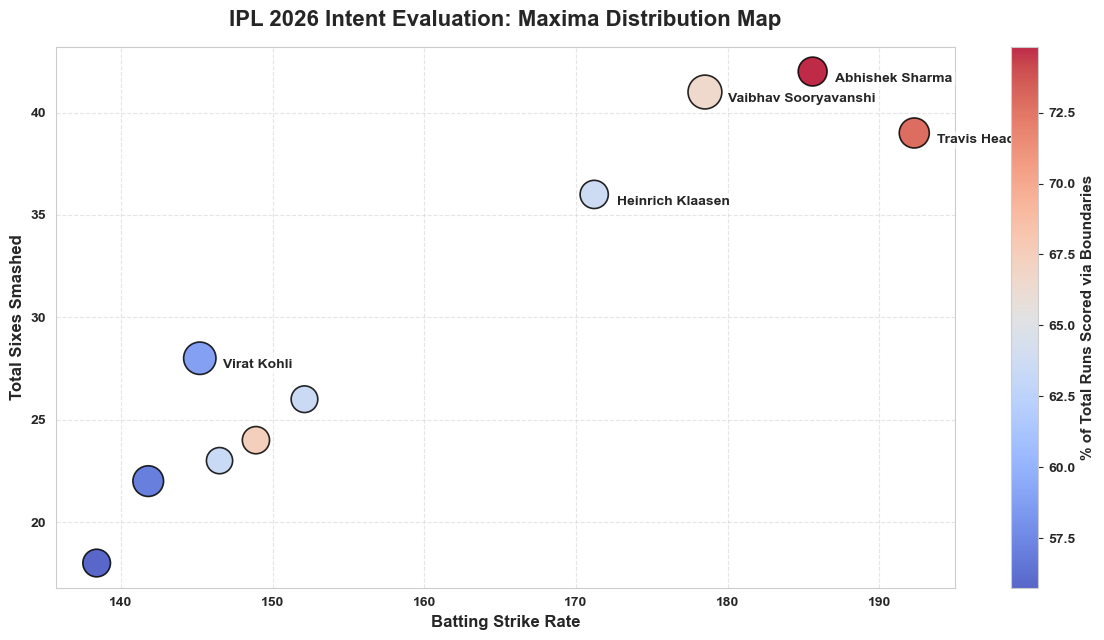

In [37]:
## 5. Aggressive Intent Matrix: Sixes vs. Boundary Percentage

import matplotlib.pyplot as plt

# Feature Engineering: Calculate percentage of runs scored strictly via boundaries
df_matrix = batting_df.copy()
df_matrix['BoundaryRuns'] = (df_matrix['Fours'] * 4) + (df_matrix['Sixes'] * 6)
df_matrix['BoundaryPct'] = (df_matrix['BoundaryRuns'] / df_matrix['Runs']) * 100

top_six_hitters = df_matrix.sort_values(by='Sixes', ascending=False).head(5)

# Scatter Map Plotting
plt.figure(figsize=(12, 6.5))

scatter = plt.scatter(
    df_matrix['StrikeRate'], 
    df_matrix['Sixes'], 
    s=df_matrix['Runs'] * 0.8,         # Bubble size maps to total run volume
    c=df_matrix['BoundaryPct'],         # Color intensity maps to boundary reliance
    cmap='coolwarm', 
    alpha=0.85, 
    edgecolors='black',
    linewidths=1.2
)

# Label top hitters directly on the scatter layout plane
for idx, row in top_six_hitters.iterrows():
    plt.text(
        row['StrikeRate'] + 1.5, 
        row['Sixes'] - 0.5, 
        row['Player'], 
        fontsize=10, 
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.6, boxstyle='round,pad=0.2', edgecolor='none')
    )

plt.title('IPL 2026 Intent Evaluation: Maxima Distribution Map', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Batting Strike Rate', fontsize=12, fontweight='bold')
plt.ylabel('Total Sixes Smashed', fontsize=12, fontweight='bold')

# Configure layout formatting for color scale bar
cbar = plt.colorbar(scatter)
cbar.set_label('% of Total Runs Scored via Boundaries', fontsize=11, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



🚀 Generating Interactive ML Profile Matrix...


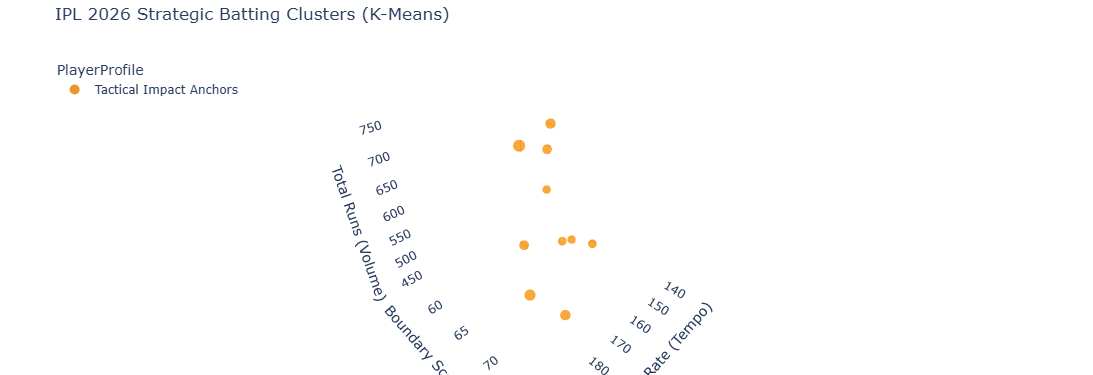

✓ Interactive asset exported successfully as 'ipl_2026_ml_dashboard.html'


In [45]:
## 6. Project Level-Up: ML Clustering & Interactive Plotly Engine

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Ensure base data is pulled from our finalized 2026 database
df_ml = batting_df.copy()

# --- STEP 1: ADVANCED FEATURE ENGINEERING ---
# Calculate boundary contribution and efficiency index
df_ml['BoundaryRuns'] = (df_ml['Fours'] * 4) + (df_ml['Sixes'] * 6)
df_ml['BoundaryPct'] = (df_ml['BoundaryRuns'] / df_ml['Runs']) * 100
df_ml['EfficiencyIndex'] = (df_ml['Runs'] * df_ml['StrikeRate']) / 100

# --- STEP 2: MACHINE LEARNING (K-MEANS CLUSTERING) ---
# Select core features for profile grouping
features = ['Runs', 'StrikeRate', 'BoundaryPct']
X = df_ml[features]

# Normalize features for accurate geometric clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit K-Means targeting 3 distinct tactical batting profiles
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['Cluster'] = kmeans.fit_predict(X_scaled)

# Map numeric clusters to strategic labels dynamically
cluster_profiles = []
for cluster in range(3):
    cluster_sub = df_ml[df_ml['Cluster'] == cluster]
    mean_sr = cluster_sub['StrikeRate'].mean()
    mean_runs = cluster_sub['Runs'].mean()
    
    if mean_sr > 190:
        cluster_profiles.append((cluster, 'Hyper-Aggressive Enforcers'))
    elif mean_runs > 650:
        cluster_profiles.append((cluster, 'Elite Volume Anchors'))
    else:
        cluster_profiles.append((cluster, 'Tactical Impact Anchors'))

profile_map = {cluster: label for cluster, label in cluster_profiles}
df_ml['PlayerProfile'] = df_ml['Cluster'].map(profile_map)

# --- STEP 3: INTERACTIVE 3D DASHBOARD GENERATION ---
print("🚀 Generating Interactive ML Profile Matrix...")

fig = px.scatter_3d(
    df_ml, 
    x='StrikeRate', 
    y='BoundaryPct', 
    z='Runs',
    color='PlayerProfile',
    size='EfficiencyIndex',
    hover_name='Player',
    hover_data={'Team': True, 'Matches': True, 'Runs': True, 'StrikeRate': ':.2f', 'PlayerProfile': False},
    title='IPL 2026 Strategic Batting Clusters (K-Means)',
    labels={'StrikeRate': 'Strike Rate (Tempo)', 'BoundaryPct': 'Boundary Score %', 'Runs': 'Total Runs (Volume)'},
    color_discrete_sequence=px.colors.qualitative.Vivid,
    opacity=0.85
)

# Refine camera optics and layout design
fig.update_layout(
    scene=dict(
        xaxis=dict(backgroundcolor="rgba(240, 240, 240, 0.5)", gridcolor="white"),
        yaxis=dict(backgroundcolor="rgba(240, 240, 240, 0.5)", gridcolor="white"),
        zaxis=dict(backgroundcolor="rgba(240, 240, 240, 0.5)", gridcolor="white")
    ),
    margin=dict(l=0, r=0, b=0, t=40),
    legend=dict(yanchor="top", y=0.95, xanchor="left", x=0.05)
)

# Display in notebook environment
fig.show()

# Export dashboard as web asset
fig.write_html("ipl_2026_ml_dashboard.html")
print("✓ Interactive asset exported successfully as 'ipl_2026_ml_dashboard.html'")